<a href="https://colab.research.google.com/github/earn438/VapeRadar01/blob/main/EDA_vaperadar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully loaded '/content/vaperadar - Sheet1.csv'.
Here are the first 5 rows and column names:
                  time  tvoc  pm2.5  humid     H0       H2     H3  Unnamed: 7  \
0  17/05/2026 16:40:50    31    1.6  47.28  29474  53041.0  47564         NaN   
1  17/05/2026 16:40:55    32    1.9  46.81  29855  55090.0  48066         NaN   
2  17/05/2026 16:41:00    23    1.8  46.33  30727  55860.0  49085         NaN   
3  17/05/2026 16:41:06    23    1.8  46.42  31336  57315.0  49435         NaN   
4  17/05/2026 16:41:12    19    1.8  46.31  31336  58077.0  50706         NaN   

   Unnamed: 8  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  

Available columns:
['time', 'tvoc', 'pm2.5', 'humid', 'H0', 'H2', 'H3', 'Unnamed: 7', 'Unnamed: 8']


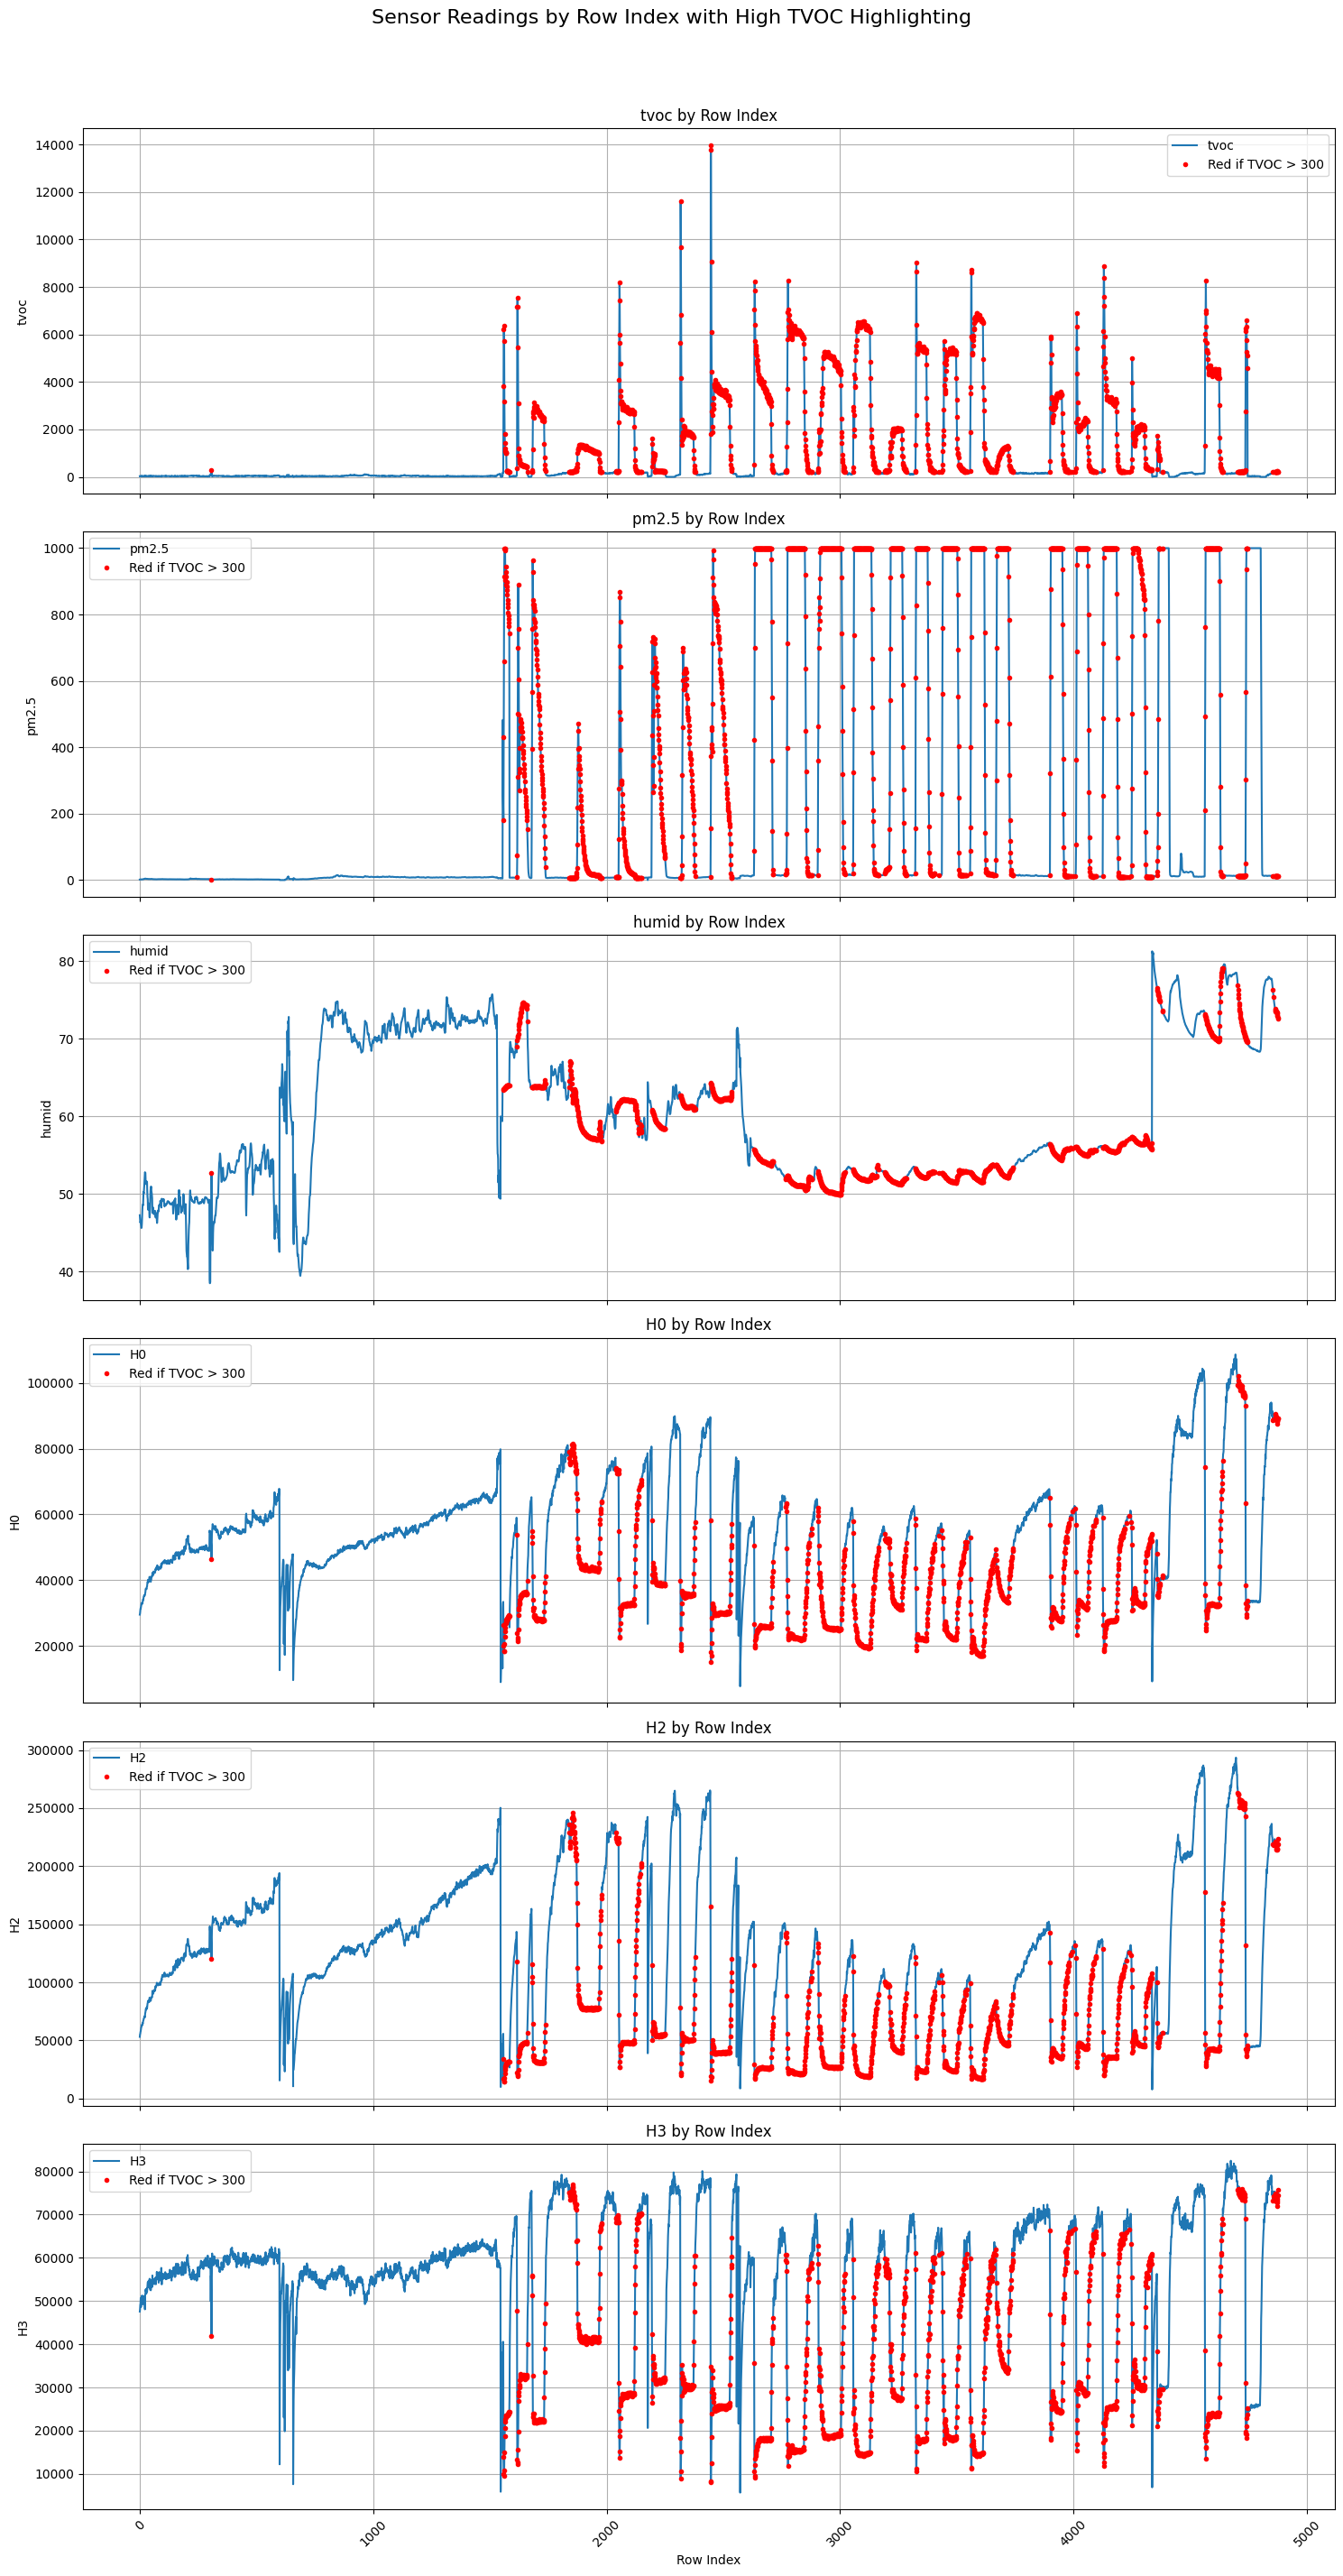

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Specify your CSV file name ---
# Replace 'your_file_name.csv' with the actual path to your CSV file.
# For example: 'my_data.csv' or '/content/data/my_data.csv'
csv_file_name = '/content/vaperadar - Sheet1.csv'

try:
    # Load the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_name)

    print(f"Successfully loaded '{csv_file_name}'.")
    print("Here are the first 5 rows and column names:")
    print(df.head())
    print("\nAvailable columns:")
    print(df.columns.tolist())

    # Convert 'time' column to datetime objects for proper time-series plotting
    df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y %H:%M:%S')

    # Add a 'label' column: 1 if tvoc > 300, else 0
    df['label'] = (df['tvoc'] > 200).astype(int)

    # Identify numerical columns to plot, excluding 'time' and 'Unnamed' columns
    channels_to_plot = [col for col in df.columns if col not in ['time', 'Unnamed: 7', 'Unnamed: 8', 'label']]

    # Create a figure to hold multiple subplots
    fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(15, 5 * len(channels_to_plot)), sharex=True)
    fig.suptitle('Sensor Readings by Row Index with High TVOC Highlighting', fontsize=16)

    # Ensure 'axes' is an array even if there's only one subplot
    if len(channels_to_plot) == 1:
        axes = [axes]

    # Find indices where tvoc is greater than 300
    tvoc_high_indices = df[df['tvoc'] > 200].index

    for i, channel in enumerate(channels_to_plot):
        # Plot all data for the current channel
        axes[i].plot(df.index, df[channel], label=channel)

        # Highlight points in red where tvoc is greater than 300
        # Ensure there are actually high tvoc values to plot
        if not tvoc_high_indices.empty:
            axes[i].plot(tvoc_high_indices, df.loc[tvoc_high_indices, channel], 'ro', markersize=3, label=f'Red if TVOC > 300') # 'ro' for red circles

        axes[i].set_ylabel(channel)
        axes[i].grid(True)
        axes[i].set_title(f'{channel} by Row Index')
        axes[i].legend(loc='best')

    plt.xlabel('Row Index')
    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent titles from overlapping
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{csv_file_name}' was not found. Please check the file name and path.")
except KeyError as e:
    print(f"Error: Column '{e}' not found in the CSV file. Please check column names.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
df['label'] = ((df['tvoc'] > 200) & (df['pm2.5'] > 50)).astype(int)

In [ ]:
# Save the DataFrame with the new 'label' column to a CSV file
output_df_csv_file = 'vaperadar_with_label.csv'
df.to_csv(output_df_csv_file, index=False)

print(f"DataFrame with 'label' column saved to '{output_df_csv_file}'.")
print("Here's a preview of the saved DataFrame:")
display(df.head())

DataFrame with 'label' column saved to 'vaperadar_with_label.csv'.
Here's a preview of the saved DataFrame:


,time,tvoc,pm2.5,humid,H0,H2,H3,Unnamed: 7,Unnamed: 8,label
0,2026-05-17 16:40:50,31,1.6,47.28,29474,53041.0,47564,NaN,NaN,0
1,2026-05-17 16:40:55,32,1.9,46.81,29855,55090.0,48066,NaN,NaN,0
2,2026-05-17 16:41:00,23,1.8,46.33,30727,55860.0,49085,NaN,NaN,0
3,2026-05-17 16:41:06,23,1.8,46.42,31336,57315.0,49435,NaN,NaN,0
4,2026-05-17 16:41:12,19,1.8,46.31,31336,58077.0,50706,NaN,NaN,0


In [ ]:
# Keep only 'tvoc', 'pm2.5', and 'label' columns
df = df[['tvoc', 'pm2.5', 'label']]

print("DataFrame after dropping unnecessary columns:")
display(df.head())
print("\nAvailable columns after filtering:")
print(df.columns.tolist())

DataFrame after dropping unnecessary columns:


,tvoc,pm2.5,label
0,31,1.6,0
1,32,1.9,0
2,23,1.8,0
3,23,1.8,0
4,19,1.8,0



Available columns after filtering:
['tvoc', 'pm2.5', 'label']


In [ ]:
# Save the current DataFrame with only the selected columns
output_csv_file_name = 'vaperadar_with_label.csv'
df.to_csv(output_csv_file_name, index=False)

print(f"The DataFrame with 'tvoc', 'pm2.5', and 'label' columns has been saved to '{output_csv_file_name}'.")

The DataFrame with 'tvoc', 'pm2.5', and 'label' columns has been saved to 'vaperadar_with_label.csv'.


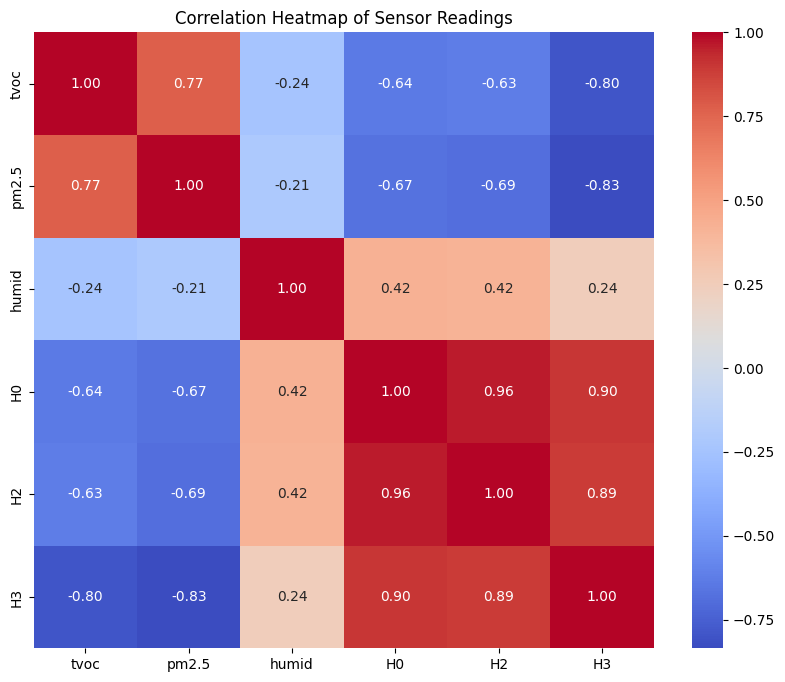

In [ ]:
import seaborn as sns

# Select only the numerical columns for the heatmap
# Exclude 'time', 'Unnamed' columns, and 'label' (as it's a target variable)
numerical_df = df[['tvoc', 'pm2.5']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Sensor Readings (tvoc, pm2.5)')
plt.show()

### Checking for Missing Data

Let's first inspect if there are any missing values in our dataset.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("\nConsider how to handle these missing values (e.g., imputation, removal).")

Missing values per column:
H2               1
Unnamed: 7    4854
Unnamed: 8    4876
dtype: int64

Consider how to handle these missing values (e.g., imputation, removal).


### Identifying Outliers using IQR Method

Now, let's identify potential outliers in the numerical sensor readings using the Interquartile Range (IQR) method. This method defines outliers as data points that fall below $Q1 - 1.5 \cdot IQR$ or above $Q3 + 1.5 \cdot IQR$, where $Q1$ is the first quartile, $Q3$ is the third quartile, and $IQR = Q3 - Q1$.

In [ ]:
numerical_columns = ['tvoc', 'pm2.5', 'humid', 'H0', 'H2', 'H3']

outlier_summary = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {"count": len(outliers), "percentage": (len(outliers) / len(df)) * 100}

    if not outliers.empty:
        print(f"\n--- Outliers for column: {col} ---")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Percentage of data: {outlier_summary[col]['percentage']:.2f}%")
        # Optionally, display some of the outlier rows
        # display(outliers[['time', col]].head())
    else:
        print(f"\nNo outliers found for column: {col}")

print("\n--- Outlier Summary ---")
for col, data in outlier_summary.items():
    print(f"Column '{col}': {data['count']} outliers ({data['percentage']:.2f}%) ")


--- Outliers for column: tvoc ---
  Number of outliers: 795
  Percentage of data: 16.30%

No outliers found for column: pm2.5

No outliers found for column: humid

--- Outliers for column: H0 ---
  Number of outliers: 78
  Percentage of data: 1.60%

No outliers found for column: H2

No outliers found for column: H3

--- Outlier Summary ---
Column 'tvoc': 795 outliers (16.30%) 
Column 'pm2.5': 0 outliers (0.00%) 
Column 'humid': 0 outliers (0.00%) 
Column 'H0': 78 outliers (1.60%) 
Column 'H2': 0 outliers (0.00%) 
Column 'H3': 0 outliers (0.00%) 


### Value Counts for 'tvoc' Column

Let's count how many times each unique 'tvoc' value appears in the dataset.

### Mean, Median, and Mode of Numerical Columns

Let's calculate the central tendency measures (mean, median, and mode) for the numerical sensor readings.

In [ ]:
numerical_columns_for_stats = ['tvoc', 'pm2.5', 'humid', 'H0', 'H2', 'H3']

print("--- Descriptive Statistics (Mean, Median, Mode) ---")
for col in numerical_columns_for_stats:
    print(f"\nColumn: {col}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    # Mode can have multiple values, so we display all of them
    modes = df[col].mode()
    if not modes.empty:
        print(f"  Mode: {modes.tolist()}")
    else:
        print("  Mode: No unique mode found")

--- Descriptive Statistics (Mean, Median, Mode) ---

Column: tvoc
  Mean: 1054.96
  Median: 153.00
  Mode: [0]

Column: pm2.5
  Mean: 254.41
  Median: 12.50
  Mode: [999.9]

Column: humid
  Mean: 60.23
  Median: 57.15
  Mode: [51.8]

Column: H0
  Mean: 49943.96
  Median: 49889.00
  Mode: [43161, 55034]

Column: H2
  Mean: 112270.73
  Median: 107418.50
  Mode: [104337.0, 106118.0, 127355.0, 130806.0]

Column: H3
  Mean: 50123.36
  Median: 56220.00
  Mode: [56315]


In [ ]:
stats_data = {}
for col in numerical_columns_for_stats:
    mean_val = df[col].mean()
    median_val = df[col].median()
    modes_val = df[col].mode().tolist()
    stats_data[col] = {'Mean': mean_val, 'Median': median_val, 'Mode': modes_val}

stats_df = pd.DataFrame.from_dict(stats_data, orient='index')

# Save to CSV
output_csv_file = 'numerical_stats.csv'
stats_df.to_csv(output_csv_file)

print(f"Statistics saved to '{output_csv_file}'.")
print("\nContent of the generated CSV file:")
display(stats_df)

Statistics saved to 'numerical_stats.csv'.

Content of the generated CSV file:


,Mean,Median,Mode
tvoc,1054.964937,153.00,[0]
pm2.5,254.414046,12.50,[999.9]
humid,60.228776,57.15,[51.8]
H0,49943.958171,49889.00,"[43161, 55034]"
H2,112270.733798,107418.50,"[104337.0, 106118.0, 127355.0, 130806.0]"
H3,50123.361288,56220.00,[56315]


In [ ]:
# Save the DataFrame with the new 'label' column to a CSV file
output_df_csv_file = 'vaperadar_with_label.csv'
df.to_csv(output_df_csv_file, index=False)

print(f"DataFrame with 'label' column saved to '{output_df_csv_file}'.")
print("Here's a preview of the saved DataFrame:")
display(df.head())

DataFrame with 'label' column saved to 'vaperadar_with_label.csv'.
Here's a preview of the saved DataFrame:


,time,tvoc,pm2.5,humid,H0,H2,H3,Unnamed: 7,Unnamed: 8,label
0,2026-05-17 16:40:50,31,1.6,47.28,29474,53041.0,47564,NaN,NaN,0
1,2026-05-17 16:40:55,32,1.9,46.81,29855,55090.0,48066,NaN,NaN,0
2,2026-05-17 16:41:00,23,1.8,46.33,30727,55860.0,49085,NaN,NaN,0
3,2026-05-17 16:41:06,23,1.8,46.42,31336,57315.0,49435,NaN,NaN,0
4,2026-05-17 16:41:12,19,1.8,46.31,31336,58077.0,50706,NaN,NaN,0


In [ ]:
# Select only the desired columns: 'tvoc', 'pm2.5', and 'label'
filtered_df = df[['tvoc', 'pm2.5', 'label']]

# Save the filtered DataFrame to a new CSV file
output_filtered_csv_file = 'filtered_vaperadar_data.csv'
filtered_df.to_csv(output_filtered_csv_file, index=False)

print(f"Filtered DataFrame saved to '{output_filtered_csv_file}'.")
print("Here's a preview of the filtered DataFrame:")
display(filtered_df.head())

Filtered DataFrame saved to 'filtered_vaperadar_data.csv'.
Here's a preview of the filtered DataFrame:


,tvoc,pm2.5,label
0,31,1.6,0
1,32,1.9,0
2,23,1.8,0
3,23,1.8,0
4,19,1.8,0
